In [2]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [4]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

BASE_DIR = r"C:\Users\PC\Downloads\PA12 FINAL\PA12-CYBERDATA-PROYECTO-FINAL-main\colores_AI"

train_ds = image_dataset_from_directory(
    BASE_DIR + r"\TRAIN",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = image_dataset_from_directory(
    BASE_DIR + r"\VAL",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = image_dataset_from_directory(
    BASE_DIR + r"\TEST",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Clases (colores):", class_names)


Found 434 files belonging to 6 classes.
Found 316 files belonging to 6 classes.
Found 328 files belonging to 6 classes.
Clases (colores): ['AMARILLO', 'AZUL', 'BLANCO', 'GRIS', 'NEGRO', 'ROJO']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)


In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    # Ojo: evitamos RandomContrast demasiado fuerte para no distorsionar color.
])


In [7]:
num_classes = len(class_names)

IMG_SIZE = (224, 224)

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False
base_model.summary()


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Config fijo
IMG_SIZE = (224, 224)

inputs = layers.Input(shape=IMG_SIZE + (3,))

# 1) Aumentación de datos
x = data_augmentation(inputs)

# 2) Preprocesamiento para MobileNetV2
x = preprocess_input(x)

# 3) Extracción de features
x = base_model(x, training=False)

# 4) Pooling
x = layers.GlobalAveragePooling2D()(x)

# 5) Capas densas
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# 6) Salida
outputs = layers.Dense(num_classes, activation="softmax")(x)

modelo_color = models.Model(inputs, outputs)

modelo_color.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_color.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint_path = "mejor_modelo_color.keras"


callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True
    )
]

hist = modelo_color.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

class Ping(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"✅ terminó epoch {epoch+1} | val_acc={logs.get('val_accuracy'):.4f} | val_loss={logs.get('val_loss'):.4f}")

hist_ft = modelo_color.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks + [Ping()],
    verbose=1
)


Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 464ms/step - accuracy: 0.4747 - loss: 1.4010 - val_accuracy: 0.6930 - val_loss: 0.8498
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 411ms/step - accuracy: 0.7166 - loss: 0.7486 - val_accuracy: 0.8196 - val_loss: 0.5557
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 410ms/step - accuracy: 0.7857 - loss: 0.5919 - val_accuracy: 0.8987 - val_loss: 0.3959
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 363ms/step - accuracy: 0.8456 - loss: 0.4620 - val_accuracy: 0.9051 - val_loss: 0.3130
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 406ms/step - accuracy: 0.8894 - loss: 0.3469 - val_accuracy: 0.9051 - val_loss: 0.2774
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 410ms/step - accuracy: 0.9032 - loss: 0.3017 - val_accuracy: 0.9335 - val_loss: 0.2348
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 349ms/step - accuracy: 0.8825 - loss: 0.2913 - val_accuracy: 0.8987 - val_loss: 0.2817
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 368ms/step - accuracy: 0.9124 - loss: 0.2645 - val_accu

In [10]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os

# ✅ ESTA es tu ruta real (según tu screenshot)
DATA_DIR = r"C:\Users\PC\Downloads\PA12 FINAL\PA12-CYBERDATA-PROYECTO-FINAL-main\colores_AI"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

# (opcional) para confirmar que existen las carpetas
print("Existe DATA_DIR:", os.path.exists(DATA_DIR))
print("Contenido:", os.listdir(DATA_DIR))

train_path = os.path.join(DATA_DIR, "TRAIN")
val_path   = os.path.join(DATA_DIR, "VAL")
test_path  = os.path.join(DATA_DIR, "TEST")

print("TRAIN existe:", os.path.exists(train_path))
print("VAL existe:", os.path.exists(val_path))
print("TEST existe:", os.path.exists(test_path))

train_ds = image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

test_ds = image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Clases:", class_names)
print("Num clases:", num_classes)


Existe DATA_DIR: True
Contenido: ['TEST', 'TRAIN', 'VAL']
TRAIN existe: True
VAL existe: True
TEST existe: True
Found 434 files belonging to 6 classes.
Found 316 files belonging to 6 classes.
Found 328 files belonging to 6 classes.
Clases: ['AMARILLO', 'AZUL', 'BLANCO', 'GRIS', 'NEGRO', 'ROJO']
Num clases: 6


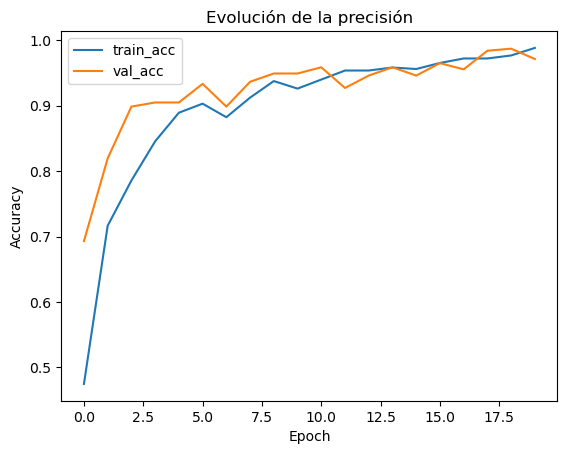

In [11]:
plt.plot(hist.history["accuracy"], label="train_acc")
plt.plot(hist.history["val_accuracy"], label="val_acc")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución de la precisión")
plt.show()


In [12]:
# Descongelar parcialmente la base
base_model.trainable = True

# Opcional: congelar primeras N capas para no destruir lo aprendido
for layer in base_model.layers[:-40]:
    layer.trainable = False

modelo_color.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist_ft = modelo_color.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8249 - loss: 0.5053 - val_accuracy: 0.9715 - val_loss: 0.0805
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 820ms/step - accuracy: 0.8525 - loss: 0.4091 - val_accuracy: 0.9747 - val_loss: 0.0846
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 960ms/step - accuracy: 0.8779 - loss: 0.3058 - val_accuracy: 0.9684 - val_loss: 0.0948
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 944ms/step - accuracy: 0.9101 - loss: 0.2248 - val_accuracy: 0.9684 - val_loss: 0.1023
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 936ms/step - accuracy: 0.9147 - loss: 0.1913 - val_accuracy: 0.9557 - val_loss: 0.1100


In [13]:
class Ping(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"✅ terminó epoch {epoch+1} | val_acc={logs.get('val_accuracy'):.4f} | val_loss={logs.get('val_loss'):.4f}")

hist_ft = modelo_color.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks + [Ping()],
    verbose=1
)


Epoch 1/10
✅ terminó epoch 1 | val_acc=0.9747 | val_loss=0.0828 0s 561ms/step - accuracy: 0.8988 - loss: 0.2839
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 963ms/step - accuracy: 0.8986 - loss: 0.2964 - val_accuracy: 0.9747 - val_loss: 0.0828
Epoch 2/10
✅ terminó epoch 2 | val_acc=0.9778 | val_loss=0.0925 0s 561ms/step - accuracy: 0.9055 - loss: 0.2473
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 964ms/step - accuracy: 0.9032 - loss: 0.2760 - val_accuracy: 0.9778 - val_loss: 0.0925
Epoch 3/10
✅ terminó epoch 3 | val_acc=0.9652 | val_loss=0.1043 0s 545ms/step - accuracy: 0.9166 - loss: 0.2414
14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 812ms/step - accuracy: 0.9194 - loss: 0.2225 - val_accuracy: 0.9652 - val_loss: 0.1043
Epoch 4/10
✅ terminó epoch 4 | val_acc=0.9525 | val_loss=0.1214 0s 564ms/step - accuracy: 0.9439 - loss: 0.1628
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 962ms/step - accuracy: 0.9194 - loss: 0.2063 - val_accuracy: 0.9525 - val_loss: 0.1214
Epoch 5/10
✅ terminó epoch 5 | val_acc=0.9494 | val_loss=0.1366 0s 545ms/step - 

In [15]:
from tensorflow.keras.utils import load_img, img_to_array

def predecir_color(ruta_img):
    img = load_img(ruta_img, target_size=img_size)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)  # shape (1, h, w, 3)

    # Pasar por el mismo pipeline que en entrenamiento
    arr_aug = preprocess_input(arr)
    preds = modelo_color.predict(arr_aug)
    idx = np.argmax(preds[0])
    prob = preds[0][idx]
    return class_names[idx], float(prob)

# Ejemplo:
# color, prob = predecir_color(r"C:\ruta\a\una_foto.jpg")
# print("Color predicho:", color, "con probabilidad", prob)


In [19]:
# Tamaño de imagen (DEBE coincidir con el entrenamiento)
img_size = (224, 224)

# Importaciones necesarias
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [38]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


# 1) Cargar el mejor modelo guardado
modelo_color = tf.keras.models.load_model("mejor_modelo_color.keras")

# 2) Asegurar variables consistentes con entrenamiento
IMG_SIZE = (224, 224)
class_names = ['AMARILLO', 'AZUL', 'BLANCO', 'GRIS', 'NEGRO', 'ROJO']  

def predecir_color(ruta_img, topk=3):
    # Cargar y preparar imagen
    img = load_img(ruta_img, target_size=IMG_SIZE)
    x = img_to_array(img)                  # (224,224,3) float32
    x = np.expand_dims(x, axis=0)          # (1,224,224,3)
    x = preprocess_input(x)                # mismo preprocess que MobileNetV2

    # Predicción
    probs = modelo_color.predict(x, verbose=0)[0]
    idxs = np.argsort(probs)[::-1][:topk]

    # Resultado top-k
    resultados = [(class_names[i], float(probs[i])) for i in idxs]
    return resultados

# Ejemplo:
ruta = r"C:\Users\PC\Downloads\PA12 FINAL\PA12-CYBERDATA-PROYECTO-FINAL-main\colores_AI\TRAIN\BLANCO\00107.jpg"
print(predecir_color(ruta, topk=3))



[('NEGRO', 0.47430169582366943), ('GRIS', 0.24934451282024384), ('AZUL', 0.2197520136833191)]


In [24]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

DATA_DIR = r"C:\Users\PC\Downloads\PA12 FINAL\PA12-CYBERDATA-PROYECTO-FINAL-main\colores_AI"
IMG_SIZE = (224,224)
BATCH_SIZE = 16

train_ds = image_dataset_from_directory(
    DATA_DIR + r"\TRAIN",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = image_dataset_from_directory(
    DATA_DIR + r"\VAL",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = image_dataset_from_directory(
    DATA_DIR + r"\TEST",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Clases:", class_names)


Found 434 files belonging to 6 classes.
Found 316 files belonging to 6 classes.
Found 328 files belonging to 6 classes.
Clases: ['AMARILLO', 'AZUL', 'BLANCO', 'GRIS', 'NEGRO', 'ROJO']


In [25]:
import numpy as np
import tensorflow as tf

y_true = []
y_pred = []

for x, y in test_ds:
    p = modelo_color.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(p, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(class_names)).numpy()
print("Confusion Matrix:\n", cm)

acc = (y_true == y_pred).mean()
print("Test accuracy:", acc)

Confusion Matrix:
 [[ 12   0   0   0   0   0]
 [  0  25   0   1   1   0]
 [  0   0  22   2   0   0]
 [  0   0   0  34   1   0]
 [  0   0   0   3  93   0]
 [  0   0   0   0   0 134]]
Test accuracy: 0.975609756097561


In [27]:
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

img_size = (224,224)

def predecir_color(ruta_img):
    img = load_img(ruta_img, target_size=(256, 256))  # más grande para recortar
    arr = img_to_array(img)

    # Recorte central (reduce “ruido” del fondo)
    h, w, _ = arr.shape
    crop = arr[h//8: h*7//8, w//8: w*7//8]  # recorta ~75% central
    crop = tf.image.resize(crop, img_size).numpy()

    x = np.expand_dims(crop, axis=0)
    x = preprocess_input(x)

    preds = modelo_color.predict(x, verbose=0)[0]
    idx = int(np.argmax(preds))
    return class_names[idx], float(preds[idx])
